# Phishing URL Detection — Feature Engineering

Builds the engineered feature dataset from raw URL text files.

**Input:** `datasets/train.txt`, `datasets/val.txt`, `datasets/test.txt`  
**Output:** `datasets/phishing_url_features.csv`

**Features produced (25 + label):**

| Category | Features |
|---|---|
| Length | URLLength, DomainLength, TLDLength, PathLength, PathDepth |
| Subdomain | NoOfSubDomain, SubdomainLength |
| Character composition | NoOfLettersInURL, NoOfDigitsInURL, LetterRatioInURL, DigitRatioInURL, NoOfSpecialCharsInURL, NoOfDots, NoOfDashInURL |
| Binary indicators | IsHTTPS, HasIPAddress, HasHyphenInDomain, HasSuspiciousKeyword, DomainHasNumber, HasAtSymbol, HasDoubleSlashInPath, URLHasPort, HasHexEncoding |
| Complexity | DomainEntropy, NoOfQueryParams |

## SECTION 1 — Library Imports

In [1]:
import pandas as pd
import numpy as np
import re
import ipaddress
import tldextract
from urllib.parse import urlparse, parse_qs
from pathlib import Path

pd.set_option('display.max_colwidth', 140)
print('Libraries imported successfully.')

Libraries imported successfully.


## SECTION 2 — Load and Clean Dataset

Loads all `.txt` files from `datasets/`, auto-detects delimiters, standardises labels, and removes nulls, duplicates, and conflicting-label URLs.

### 2.1 Parsing helpers

In [2]:
def detect_separator(sample_line: str):
    candidates = ['\t', ',', ';', '|']
    counts = {sep: sample_line.count(sep) for sep in candidates}
    best_sep = max(counts, key=counts.get)
    return best_sep if counts[best_sep] > 0 else None


def parse_line_to_url_label(line: str, default_sep=None):
    line = line.strip()
    if not line:
        return None
    sep = default_sep if default_sep is not None else detect_separator(line)
    parts = [p.strip() for p in line.split(sep)] if sep else line.split()
    if len(parts) < 2:
        return None
    first, last = parts[0].lower(), parts[-1].lower()
    if first in {'0', '1', 'phishing', 'legitimate'}:
        raw_label, url = first, sep.join(parts[1:]).strip() if sep else ' '.join(parts[1:])
    elif last in {'0', '1', 'phishing', 'legitimate'}:
        raw_label, url = last, sep.join(parts[:-1]).strip() if sep else ' '.join(parts[:-1])
    else:
        return None
    label = {'1': 1, '0': 0, 'phishing': 1, 'legitimate': 0}.get(raw_label)
    if label is None or not url:
        return None
    return {'url': url, 'label': label}


def load_txt_dataset(file_path: Path):
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    first_non_empty = next((ln.strip() for ln in lines if ln.strip()), '')
    sep = detect_separator(first_non_empty)
    rows = [r for ln in lines if (r := parse_line_to_url_label(ln, sep)) is not None]
    return pd.DataFrame(rows, columns=['url', 'label'])

### 2.2 Load and aggregate files

In [3]:
base_path = Path('datasets')
all_txt_files = sorted(base_path.glob('*.txt'))
if not all_txt_files:
    raise FileNotFoundError('No .txt files found in ./datasets')

parts = []
for fp in all_txt_files:
    chunk = load_txt_dataset(fp)
    print(f'Loaded {fp.name}: {len(chunk):,} rows')
    parts.append(chunk)

raw_df = pd.concat(parts, ignore_index=True)
print(f'\nRaw aggregated rows: {len(raw_df):,}')

Loaded test.txt: 515,080 rows
Loaded train.txt: 3,641,986 rows
Loaded val.txt: 1,045,775 rows

Raw aggregated rows: 5,202,841


### 2.3 Clean and standardise

In [4]:
df = raw_df[['url', 'label']].copy()
df['url'] = df['url'].astype(str).str.strip()
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df.dropna(subset=['url', 'label'])
df = df[df['url'] != '']
df['label'] = df['label'].astype(int)
df = df[df['label'].isin({0, 1})]
df = df.drop_duplicates(subset=['url', 'label'])

conflict_urls = df.groupby('url')['label'].nunique()
conflict_urls = conflict_urls[conflict_urls > 1].index
if len(conflict_urls) > 0:
    df = df[~df['url'].isin(conflict_urls)]

df = df.reset_index(drop=True)
print(f'Clean dataset: {len(df):,} rows')
print(f'Phishing: {(df["label"]==1).sum():,} | Legitimate: {(df["label"]==0).sum():,}')

Clean dataset: 5,183,050 rows
Phishing: 2,301,110 | Legitimate: 2,881,940


## SECTION 3 — Feature Extraction Functions

Helper functions for extracting URL structural features. Base helpers are from the EDA analysis. Extended helpers are new features.

### 3.1 Base feature helpers

In [5]:
SUSPICIOUS_KEYWORDS = [
    'login', 'verify', 'secure', 'account', 'update', 'confirm',
    'bank', 'password', 'signin', 'paypal', 'webscr', 'token',
    'auth', 'free', 'bonus', 'prize',
]


def extract_parts(url: str):
    ext = tldextract.extract(url)
    subdomain = ext.subdomain or ''
    sub_parts = [p for p in subdomain.split('.') if p]
    while sub_parts and sub_parts[0].lower() == 'www':
        sub_parts.pop(0)
    domain = ext.domain or ''
    tld = ext.suffix.split('.')[-1].lower() if ext.suffix else 'unknown'
    return '.'.join(sub_parts), domain, tld


def count_subdomains(subdomain: str) -> int:
    return len([p for p in subdomain.split('.') if p]) if subdomain else 0


def has_ip_address(url: str) -> int:
    host = (urlparse(url).hostname or '').strip().strip('[]')
    try:
        ipaddress.ip_address(host)
        return 1
    except ValueError:
        return 0


def shannon_entropy(text: str) -> float:
    text = str(text)
    if not text:
        return 0.0
    values = pd.Series(list(text)).value_counts(normalize=True)
    return float(-(values * np.log2(values)).sum())

### 3.2 Extended feature helpers (new)

In [6]:
def has_at_symbol(url: str) -> int:
    """@ in URL is a classic phishing trick to disguise the real domain."""
    return int('@' in url)


def has_double_slash_in_path(url: str) -> int:
    """// after the netloc signals path obfuscation."""
    return int('//' in (urlparse(url).path or ''))


def count_dots(url: str) -> int:
    """Total dot count — phishing URLs chain many subdomains."""
    return url.count('.')


def has_port(url: str) -> int:
    """Non-standard port is unusual for legitimate sites."""
    try:
        return int(bool(urlparse(url).port))
    except ValueError:
        return 0


def count_query_params(url: str) -> int:
    """Excessive query params can signal tracking or obfuscation."""
    return len(parse_qs(urlparse(url).query))


def path_depth(url: str) -> int:
    """Number of path segments — deep paths are common in phishing."""
    return len([p for p in (urlparse(url).path or '').split('/') if p])


def has_hex_encoding(url: str) -> int:
    """Percent-encoding (%xx) used to hide malicious content."""
    return int(bool(re.search(r'%[0-9a-fA-F]{2}', url)))


def get_subdomain_length(url: str) -> int:
    """Character length of subdomain (excl. www) — long subdomains are suspicious."""
    ext = tldextract.extract(url)
    sub_parts = [p for p in (ext.subdomain or '').split('.') if p and p.lower() != 'www']
    return len('.'.join(sub_parts))


def count_dashes(url: str) -> int:
    """Total dash count in full URL."""
    return url.count('-')

## SECTION 4 — Build Feature Table

Extracts all 25 features from the clean URL dataset.

### 4.1 Extract features

In [7]:
features_df = df.copy()

# Parse URL components
parts_result = features_df['url'].apply(extract_parts)
features_df[['_subdomain', 'Domain', 'TLD']] = pd.DataFrame(parts_result.tolist(), index=features_df.index)
features_df['Domain'] = features_df['Domain'].astype(str).str.lower()
features_df['TLD'] = features_df['TLD'].astype(str).str.lower()

# --- Base features ---
features_df['URLLength']             = features_df['url'].str.len()
features_df['DomainLength']          = features_df['Domain'].str.len()
features_df['TLDLength']             = features_df['TLD'].str.len()
features_df['NoOfSubDomain']         = features_df['_subdomain'].apply(count_subdomains)
features_df['NoOfLettersInURL']      = features_df['url'].apply(lambda u: len(re.findall(r'[A-Za-z]', u)))
features_df['NoOfDigitsInURL']       = features_df['url'].apply(lambda u: len(re.findall(r'[0-9]', u)))
features_df['LetterRatioInURL']      = np.where(features_df['URLLength'] > 0, features_df['NoOfLettersInURL'] / features_df['URLLength'], 0.0)
features_df['DigitRatioInURL']       = np.where(features_df['URLLength'] > 0, features_df['NoOfDigitsInURL'] / features_df['URLLength'], 0.0)
features_df['NoOfSpecialCharsInURL'] = features_df['url'].apply(lambda u: len(re.findall(r'[^A-Za-z0-9]', u)))
features_df['PathLength']            = features_df['url'].apply(lambda u: len(urlparse(u).path or ''))
features_df['IsHTTPS']               = features_df['url'].str.lower().str.startswith('https').astype(int)
features_df['HasIPAddress']          = features_df['url'].apply(has_ip_address)
features_df['HasHyphenInDomain']     = features_df['Domain'].apply(lambda d: int('-' in (d or '')))
features_df['HasSuspiciousKeyword']  = features_df['url'].apply(
    lambda u: int(any(kw in u.lower() for kw in SUSPICIOUS_KEYWORDS)))
features_df['DomainEntropy']         = features_df['Domain'].apply(shannon_entropy)
features_df['DomainHasNumber']       = features_df['Domain'].apply(
    lambda d: int(bool(re.search(r'\d', str(d or '')))))

# --- Extended features ---
features_df['HasAtSymbol']           = features_df['url'].apply(has_at_symbol)
features_df['HasDoubleSlashInPath']  = features_df['url'].apply(has_double_slash_in_path)
features_df['NoOfDots']              = features_df['url'].apply(count_dots)
features_df['URLHasPort']            = features_df['url'].apply(has_port)
features_df['NoOfQueryParams']       = features_df['url'].apply(count_query_params)
features_df['PathDepth']             = features_df['url'].apply(path_depth)
features_df['HasHexEncoding']        = features_df['url'].apply(has_hex_encoding)
features_df['SubdomainLength']       = features_df['url'].apply(get_subdomain_length)
features_df['NoOfDashInURL']         = features_df['url'].apply(count_dashes)

print(f'Feature extraction complete: {len(features_df):,} rows')

Feature extraction complete: 5,183,050 rows


### 4.2 Finalise columns and save

In [8]:
FINAL_COLUMNS = [
    'url', 'URLLength', 'Domain', 'DomainLength', 'TLD', 'TLDLength',
    'NoOfSubDomain', 'SubdomainLength',
    'NoOfLettersInURL', 'NoOfDigitsInURL', 'LetterRatioInURL', 'DigitRatioInURL',
    'NoOfSpecialCharsInURL', 'NoOfDots', 'NoOfDashInURL',
    'PathLength', 'PathDepth',
    'IsHTTPS', 'HasIPAddress', 'HasHyphenInDomain', 'HasSuspiciousKeyword',
    'DomainHasNumber', 'DomainEntropy',
    'HasAtSymbol', 'HasDoubleSlashInPath', 'URLHasPort', 'HasHexEncoding',
    'NoOfQueryParams',
    'label',
]

final_df = features_df[FINAL_COLUMNS].copy()

output_path = 'datasets/phishing_url_features.csv'
final_df.to_csv(output_path, index=False)
print(f'Saved: {output_path}')
print(f'Rows: {len(final_df):,} | Columns: {len(final_df.columns)} ({len(final_df.columns)-1} features + label)')

Saved: datasets/phishing_url_features.csv
Rows: 5,183,050 | Columns: 29 (28 features + label)


## SECTION 5 — Feature Summary

In [9]:
COLUMN_DESCRIPTIONS = {
    'url':                   'Original URL string',
    'URLLength':             'Total characters in URL',
    'Domain':                'Extracted second-level domain (lowercased)',
    'DomainLength':          'Characters in domain',
    'TLD':                   'Extracted top-level domain (rightmost suffix label)',
    'TLDLength':             'Characters in TLD',
    'NoOfSubDomain':         'Number of subdomain levels (excl. www)',
    'SubdomainLength':       'Character length of subdomain string (excl. www) [NEW]',
    'NoOfLettersInURL':      'Alphabetic character count in URL',
    'NoOfDigitsInURL':       'Numeric character count in URL',
    'LetterRatioInURL':      'Proportion of alphabetic chars (0-1)',
    'DigitRatioInURL':       'Proportion of numeric chars (0-1)',
    'NoOfSpecialCharsInURL': 'Count of non-alphanumeric characters',
    'NoOfDots':              'Total dot count in URL [NEW]',
    'NoOfDashInURL':         'Total dash count in full URL [NEW]',
    'PathLength':            'Character length of URL path',
    'PathDepth':             'Number of path segments [NEW]',
    'IsHTTPS':               '1 if URL uses HTTPS',
    'HasIPAddress':          '1 if host is an IP address',
    'HasHyphenInDomain':     '1 if domain contains hyphen',
    'HasSuspiciousKeyword':  '1 if URL contains a suspicious keyword',
    'DomainHasNumber':       '1 if domain contains at least one digit',
    'DomainEntropy':         'Shannon entropy of domain string (base 2)',
    'HasAtSymbol':           '1 if URL contains @ — domain spoofing indicator [NEW]',
    'HasDoubleSlashInPath':  '1 if path contains // — path obfuscation [NEW]',
    'URLHasPort':            '1 if URL specifies a non-standard port [NEW]',
    'HasHexEncoding':        '1 if URL contains %xx hex encoding [NEW]',
    'NoOfQueryParams':       'Number of query parameters [NEW]',
    'label':                 'Target: 1=phishing, 0=legitimate',
}

summary_df = pd.DataFrame([
    {'Feature': col, 'Description': COLUMN_DESCRIPTIONS.get(col, ''),
     'DType': str(final_df[col].dtype),
     'NullCount': int(final_df[col].isna().sum())}
    for col in final_df.columns
])

print(f'Total features: {len(final_df.columns) - 1} (excl. label)')
display(summary_df)

# Null check
total_nulls = final_df.isnull().sum().sum()
print(f'\nTotal null values: {total_nulls:,}')

Total features: 28 (excl. label)


,Feature,Description,DType,NullCount
0,url,Original URL string,str,0
1,URLLength,Total characters in URL,int64,0
2,Domain,Extracted second-level domain (lowercased),str,0
3,DomainLength,Characters in domain,int64,0
4,TLD,Extracted top-level domain (rightmost suffix label),str,0
5,TLDLength,Characters in TLD,int64,0
6,NoOfSubDomain,Number of subdomain levels (excl. www),int64,0
7,SubdomainLength,Character length of subdomain string (excl. www) [NEW],int64,0
8,NoOfLettersInURL,Alphabetic character count in URL,int64,0
9,NoOfDigitsInURL,Numeric character count in URL,int64,0



Total null values: 0


### 6.7 Conclusion — Correlation-Based Feature Pruning

Features with |Spearman r| ≥ 0.80 are candidates for removal to reduce redundancy before modelling.
Model-based decisions (importance, SHAP) are deferred to `03_modeling.ipynb` Section 12.

| Pair | r | Drop | Keep | Reason |
|---|---|---|---|---|
| `NoOfSubDomain` / `SubdomainLength` | 0.998 | `SubdomainLength` | `NoOfSubDomain` | Near-perfect correlation; count is more interpretable |
| `NoOfDigitsInURL` / `DigitRatioInURL` | 0.976 | `NoOfDigitsInURL` | `DigitRatioInURL` | Ratio is scale-invariant (normalised by URL length) |
| `URLLength` / `NoOfLettersInURL` | 0.957 | `NoOfLettersInURL` | `URLLength` | Letter count is redundant given URL length |
| `LetterRatioInURL` / `DigitRatioInURL` | -0.867 | `LetterRatioInURL` | `DigitRatioInURL` | Ratios are near-mirror images; digit ratio is more indicative of phishing |
| `DomainLength` / `DomainEntropy` | 0.883 | — | Both kept | Correlation not extreme enough to drop on correlation alone |
| `URLLength` / `NoOfSpecialCharsInURL` | 0.887 | — | Both kept | Correlation not extreme enough to drop on correlation alone |

**Dropped (4 features):** `SubdomainLength`, `NoOfDigitsInURL`, `NoOfLettersInURL`, `LetterRatioInURL`

**Retained: 21 features** — used as `FEATURES` in `03_modeling.ipynb`.

### 6.0 Analysis setup

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 5)})

CLASS_LABELS = {0: 'Legitimate', 1: 'Phishing'}
CLASS_COLORS = {'Legitimate': '#239DD9', 'Phishing': '#FF911E'}

# Use final_df already in memory (or reload if running this section standalone)
try:
    _ = final_df
except NameError:
    final_df = pd.read_csv('datasets/phishing_url_features.csv')

analysis_df = final_df.copy()
analysis_df['Class'] = analysis_df['label'].map(CLASS_LABELS)

NUMERIC_FEATURES = [
    'URLLength', 'DomainLength', 'TLDLength', 'PathLength', 'PathDepth',
    'NoOfSubDomain', 'SubdomainLength',
    'NoOfLettersInURL', 'NoOfDigitsInURL', 'LetterRatioInURL', 'DigitRatioInURL',
    'NoOfSpecialCharsInURL', 'NoOfDots', 'NoOfDashInURL',
    'DomainEntropy', 'NoOfQueryParams',
]
BINARY_FEATURES = [
    'IsHTTPS', 'HasIPAddress', 'HasHyphenInDomain', 'HasSuspiciousKeyword',
    'DomainHasNumber', 'HasAtSymbol', 'HasDoubleSlashInPath',
    'URLHasPort', 'HasHexEncoding',
]

VIZ_CAP_QUANTILE = 0.995
IQR_MULTIPLIER   = 1.5

CAPS = {col: analysis_df[col].quantile(VIZ_CAP_QUANTILE) for col in NUMERIC_FEATURES}
print('Setup complete.')

Setup complete.


### 6.1 Plot helpers

In [11]:
def plot_hist(df, col, cap=None, bins=50, log_scale=True, density=False,
              title=None, xlabel=None):
    """Overlay histogram of `col` split by Class.

    Parameters
    ----------
    df         : DataFrame with 'Class' column.
    col        : Column name to plot.
    cap        : Upper x-axis limit (quantile cap). None = no cap.
    bins       : Number of histogram bins.
    log_scale  : Apply log scale to y-axis.
    density    : Plot probability density instead of counts.
    title      : Plot title (defaults to col name).
    xlabel     : x-axis label (defaults to col name).
    """
    plot_data = df[df[col] <= cap] if cap is not None else df
    col_data = plot_data[col].dropna()

    # Auto-align bins for integer features to avoid gaps
    is_integer = (col_data == col_data.astype(int)).all()
    if is_integer:
        lo, hi = int(col_data.min()), int(col_data.max())
        bin_edges = np.arange(lo, hi + 2) - 0.5  # centre bins on integers
    else:
        bin_edges = bins

    fig, ax = plt.subplots(figsize=(12, 5))
    for cls, grp in [(k, plot_data[plot_data['Class'] == k]) for k in ['Phishing', 'Legitimate']]:
        ax.hist(grp[col].dropna(), bins=bin_edges, alpha=0.6, density=density,
                label=cls, color=CLASS_COLORS[cls])
    if log_scale:
        ax.set_yscale('log')
    ax.set_xlabel(xlabel or col)
    ax.set_ylabel('Density' if density else 'Count (log)' if log_scale else 'Count')
    ax.set_title(title or col)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_binary_rate(df, col, title=None, ylabel='% of class URLs'):
    """Grouped bar chart showing the rate of a binary feature (0/1) per class.

    Parameters
    ----------
    df     : DataFrame with 'Class' column.
    col    : Binary column (values 0 or 1).
    title  : Plot title.
    ylabel : y-axis label.
    """
    rates = df.groupby('Class')[col].mean() * 100
    y_max = max(rates.max() * 1.3, 0.5)
    fig, ax = plt.subplots(figsize=(6, 5))
    bars = ax.bar(rates.index, rates.values,
                  color=[CLASS_COLORS[c] for c in rates.index], alpha=0.85)
    for bar, val in zip(bars, rates.values):
        # Place label inside bar if bar is tall enough, otherwise just above
        bar_h = bar.get_height()
        if bar_h > y_max * 0.15:
            ax.text(bar.get_x() + bar.get_width() / 2, bar_h * 0.5,
                    f'{val:.1f}%', ha='center', va='center', fontsize=11,
                    color='white', fontweight='bold')
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, bar_h + y_max * 0.02,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_title(title or col)
    ax.set_ylim(0, y_max)
    plt.tight_layout()
    plt.show()

### 6.2 Continuous Feature Distributions by Class

Each plot uses a quantile cap (99.5th percentile) to suppress extreme outliers.
Log-scale y-axis shows shape differences at both the bulk and tail of the distributions.

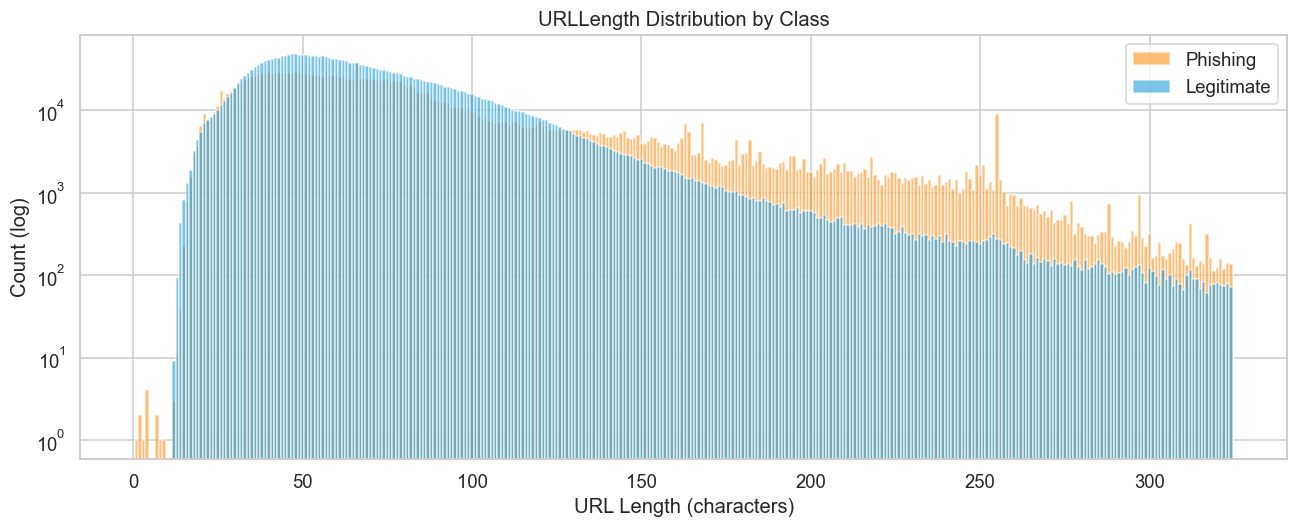

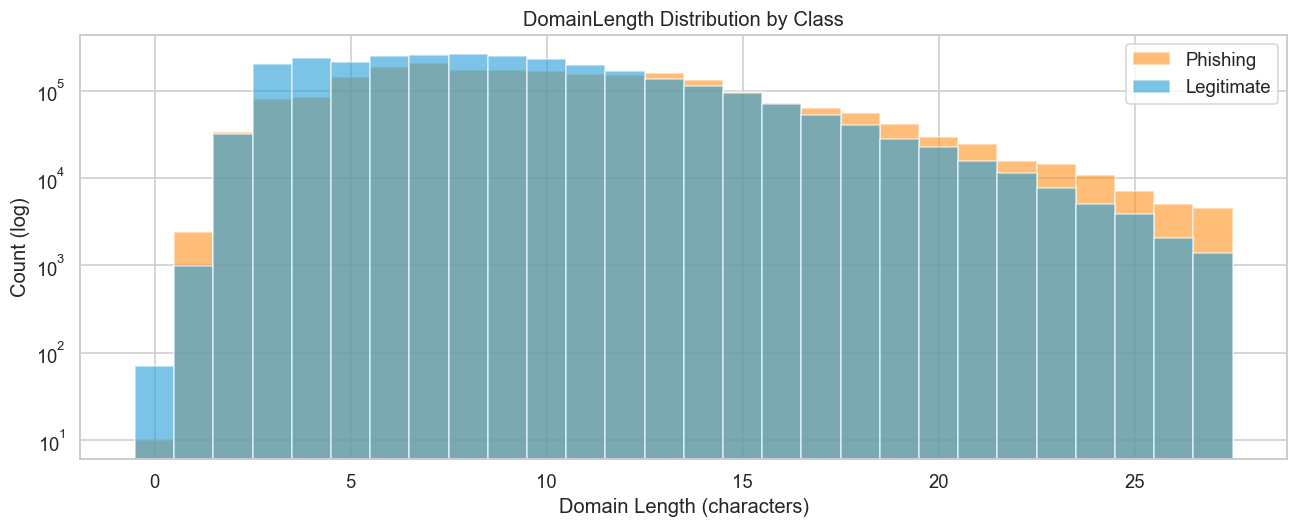

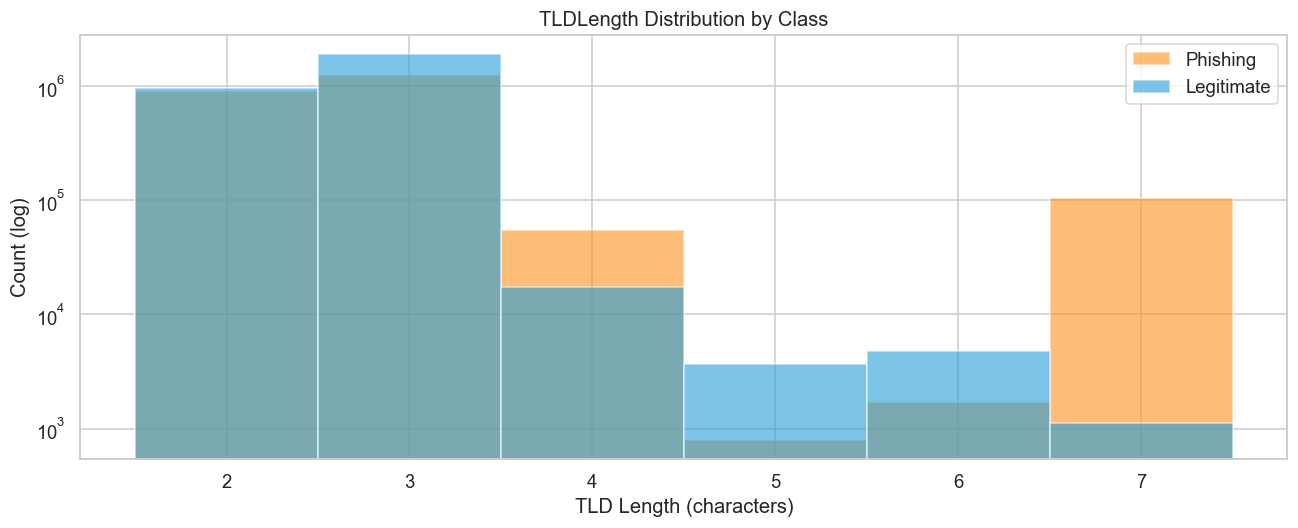

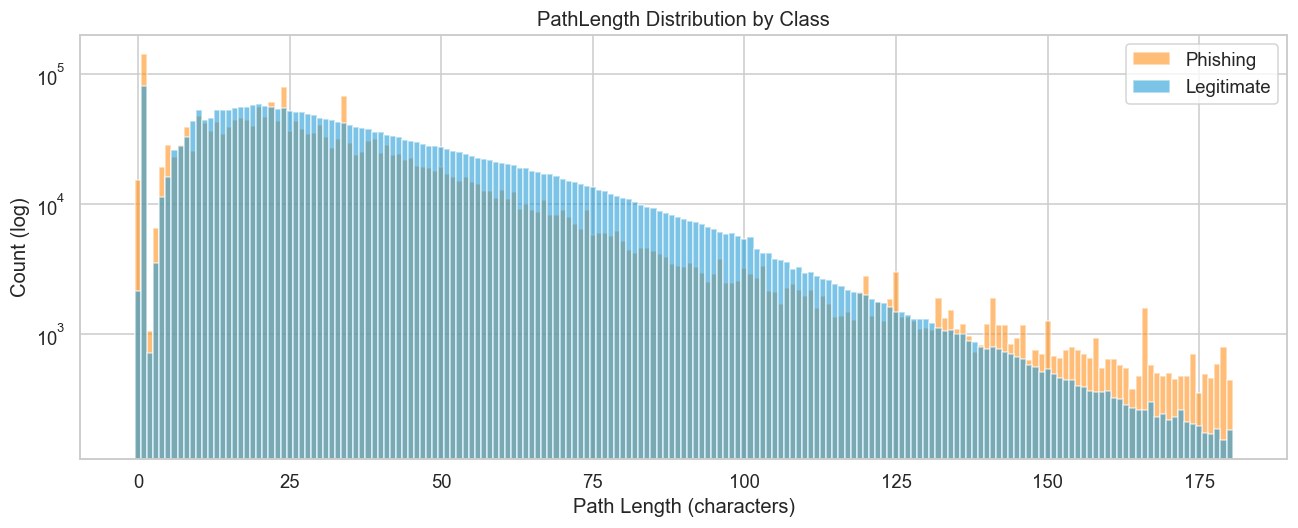

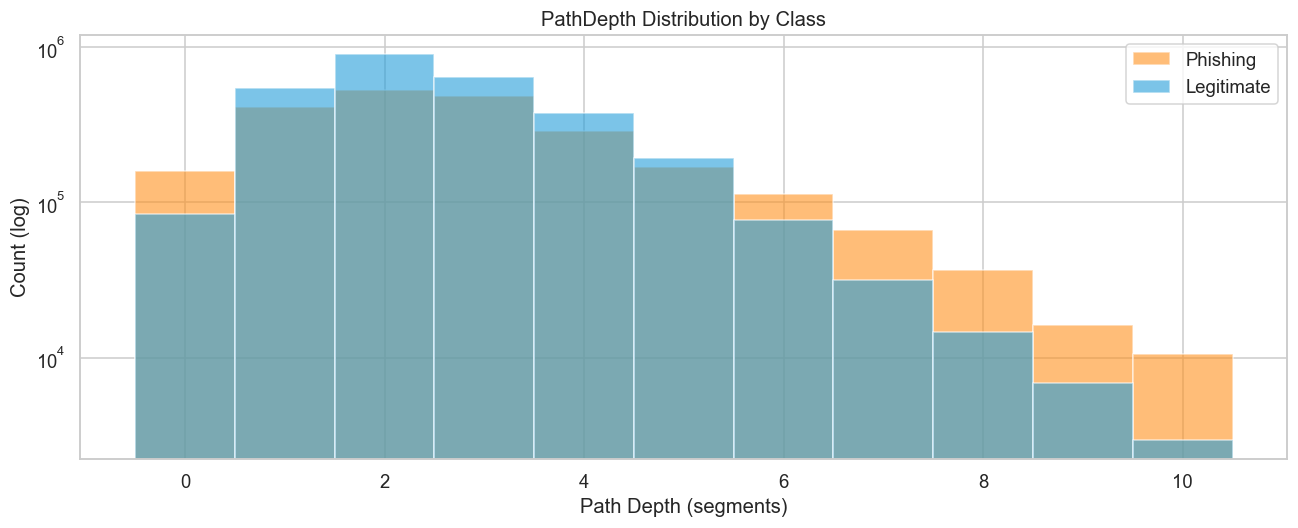

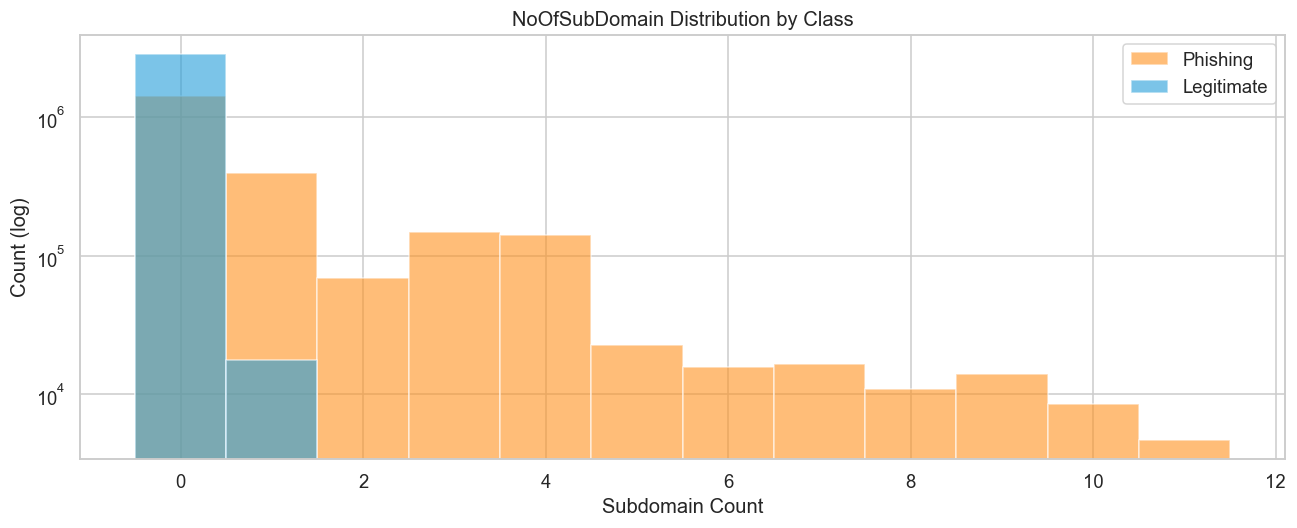

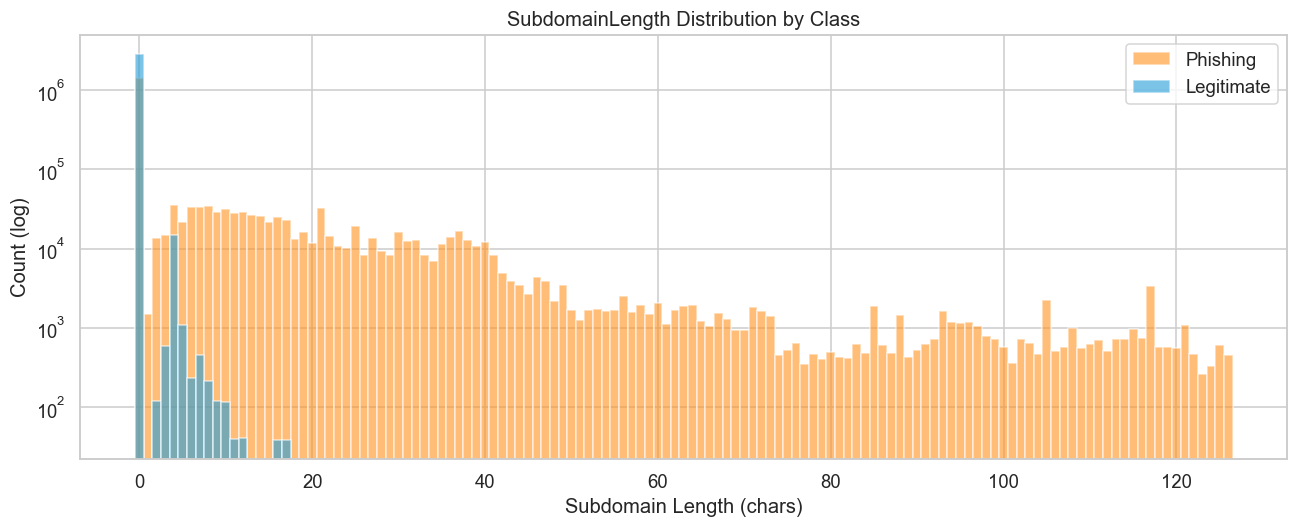

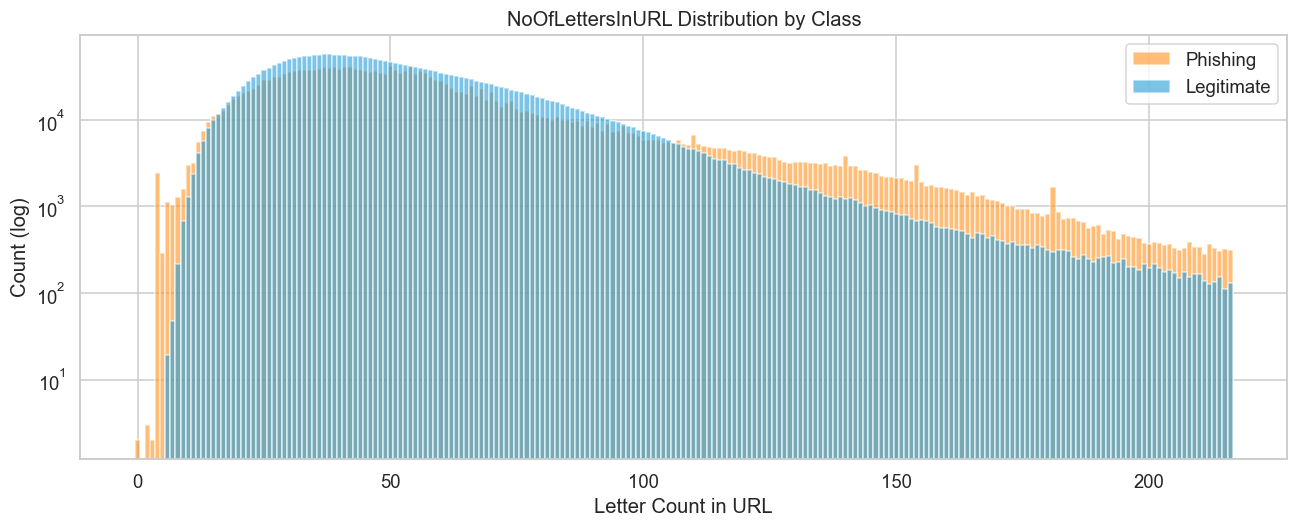

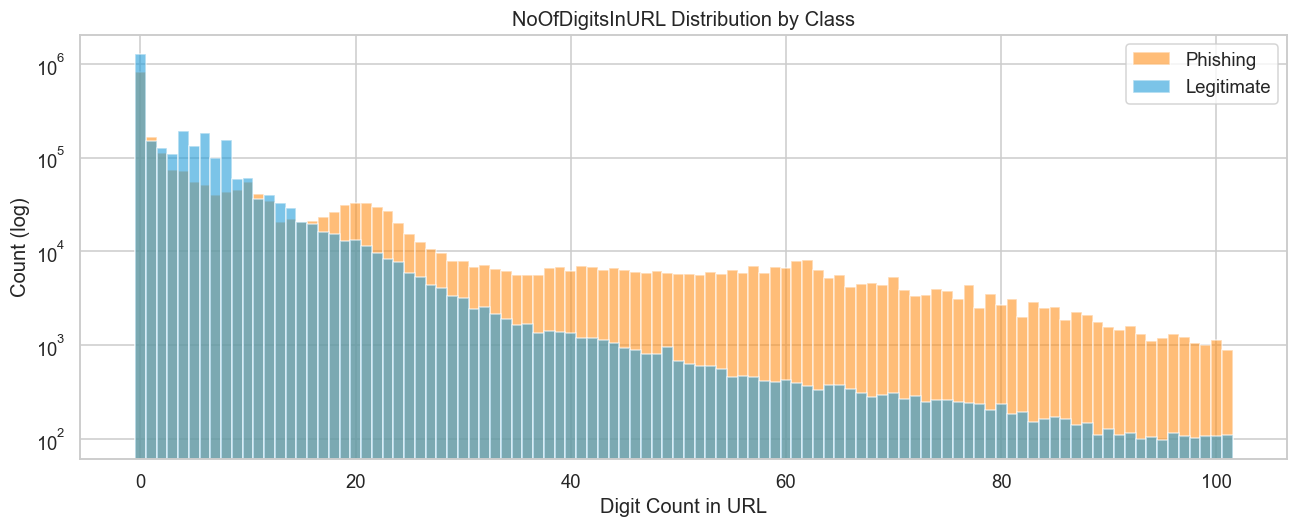

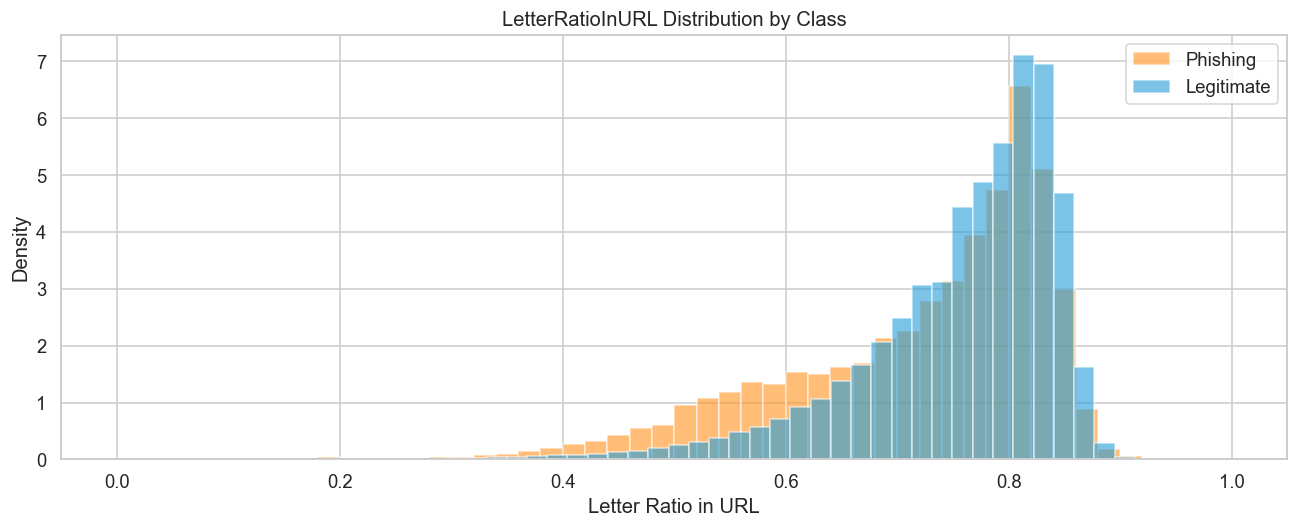

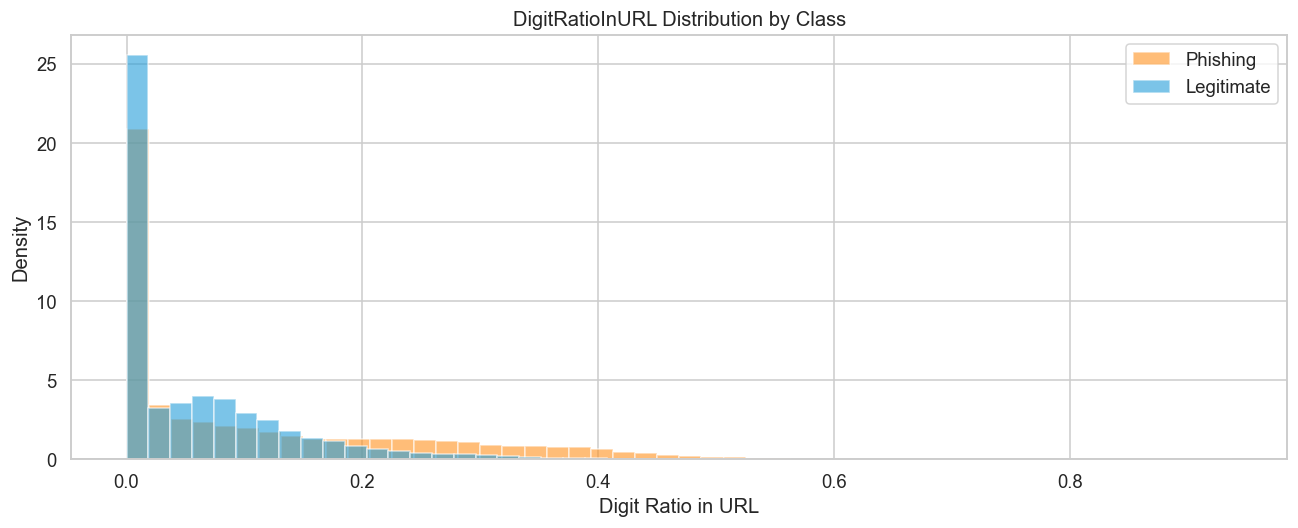

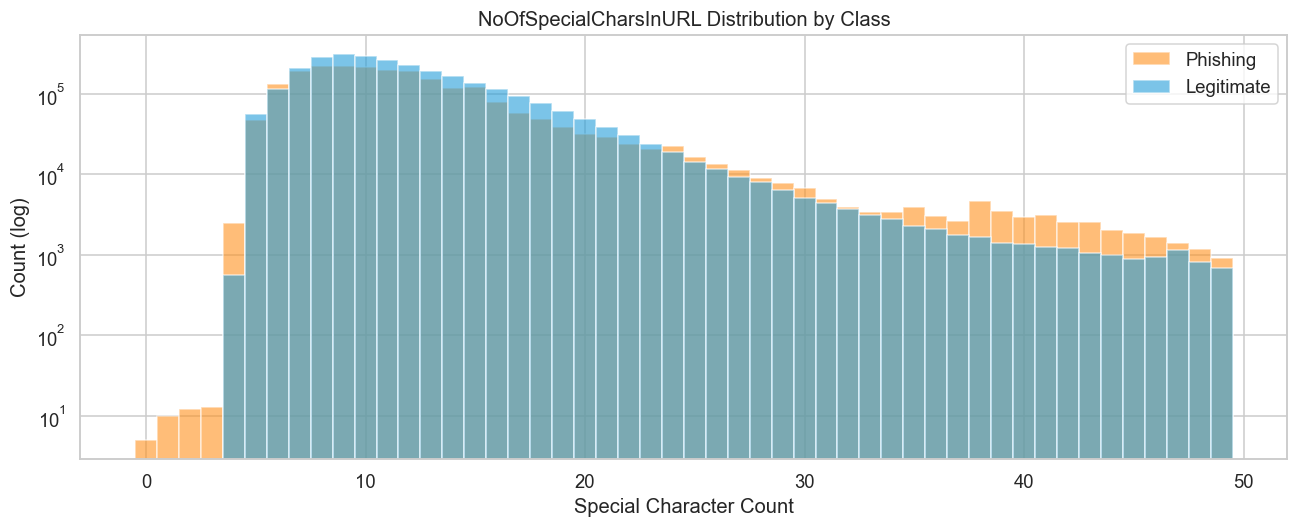

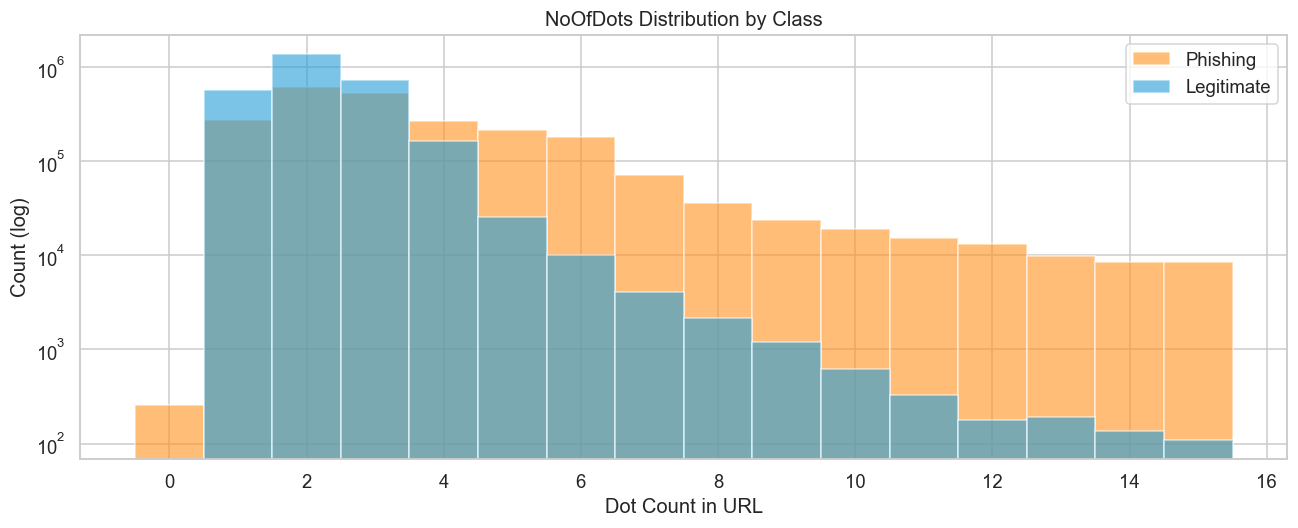

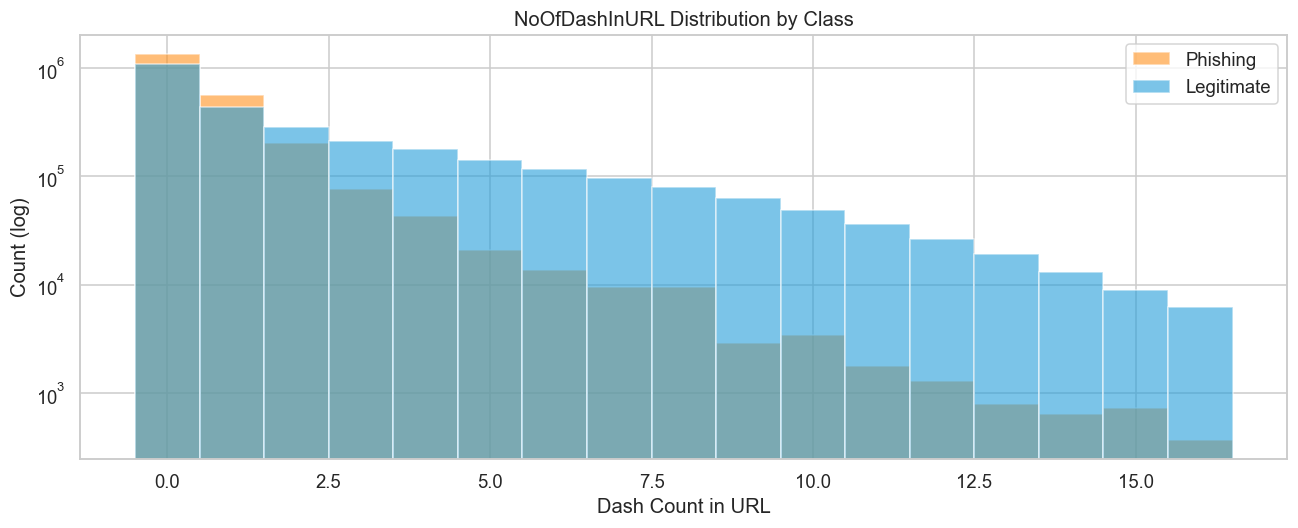

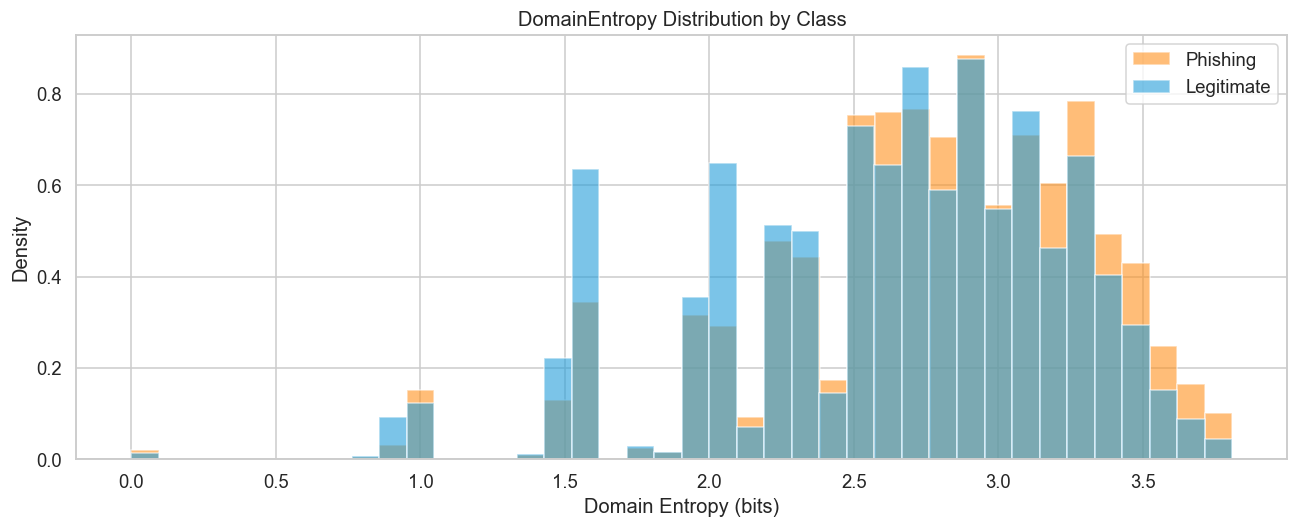

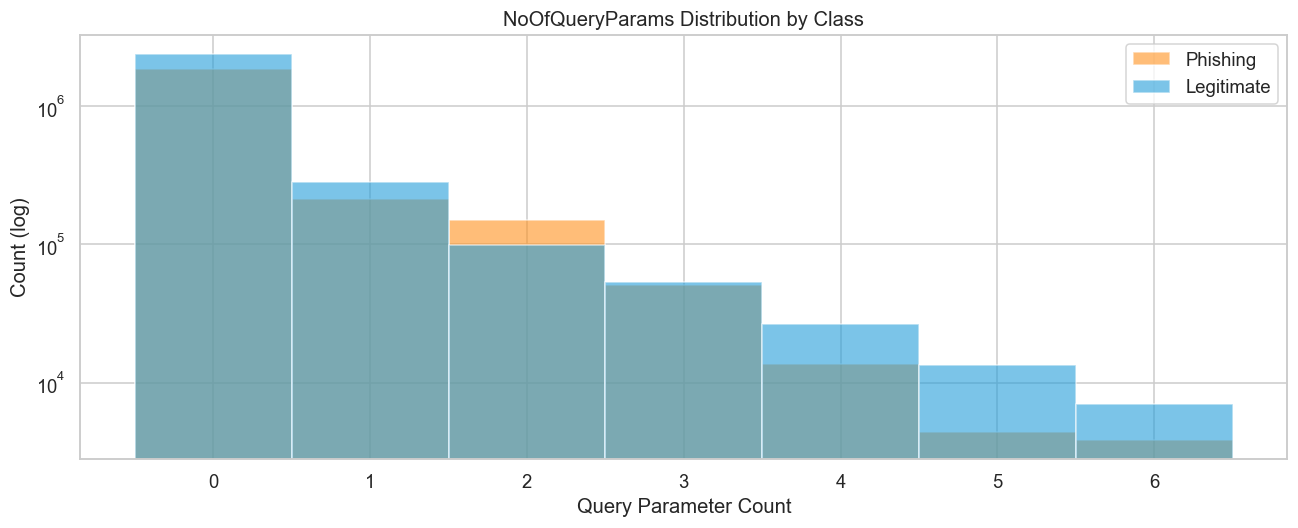

In [12]:
configs = [
    ('URLLength',             CAPS['URLLength'],             60,  True,  False, 'URL Length (characters)'),
    ('DomainLength',          CAPS['DomainLength'],          25,  True,  False, 'Domain Length (characters)'),
    ('TLDLength',             CAPS['TLDLength'],             30,  True,  False, 'TLD Length (characters)'),
    ('PathLength',            CAPS['PathLength'],            50,  True,  False, 'Path Length (characters)'),
    ('PathDepth',             CAPS['PathDepth'],             20,  True,  False, 'Path Depth (segments)'),
    ('NoOfSubDomain',         CAPS['NoOfSubDomain'],         12,  True,  False, 'Subdomain Count'),
    ('SubdomainLength',       CAPS['SubdomainLength'],       40,  True,  False, 'Subdomain Length (chars)'),
    ('NoOfLettersInURL',      CAPS['NoOfLettersInURL'],      50,  True,  False, 'Letter Count in URL'),
    ('NoOfDigitsInURL',       CAPS['NoOfDigitsInURL'],       50,  True,  False, 'Digit Count in URL'),
    ('LetterRatioInURL',      None,                          50,  False, True,  'Letter Ratio in URL'),
    ('DigitRatioInURL',       None,                          50,  False, True,  'Digit Ratio in URL'),
    ('NoOfSpecialCharsInURL', CAPS['NoOfSpecialCharsInURL'], 50,  True,  False, 'Special Character Count'),
    ('NoOfDots',              CAPS['NoOfDots'],              20,  True,  False, 'Dot Count in URL'),
    ('NoOfDashInURL',         CAPS['NoOfDashInURL'],         20,  True,  False, 'Dash Count in URL'),
    ('DomainEntropy',         CAPS['DomainEntropy'],         40,  False, True,  'Domain Entropy (bits)'),
    ('NoOfQueryParams',       CAPS['NoOfQueryParams'],       20,  True,  False, 'Query Parameter Count'),
]

for col, cap, bins, log_sc, dens, xlabel in configs:
    plot_hist(analysis_df, col, cap=cap, bins=bins, log_scale=log_sc,
              density=dens, title=f'{col} Distribution by Class', xlabel=xlabel)

### 6.3 Binary Feature Rates by Class

Percentage of URLs in each class where the binary indicator is 1.

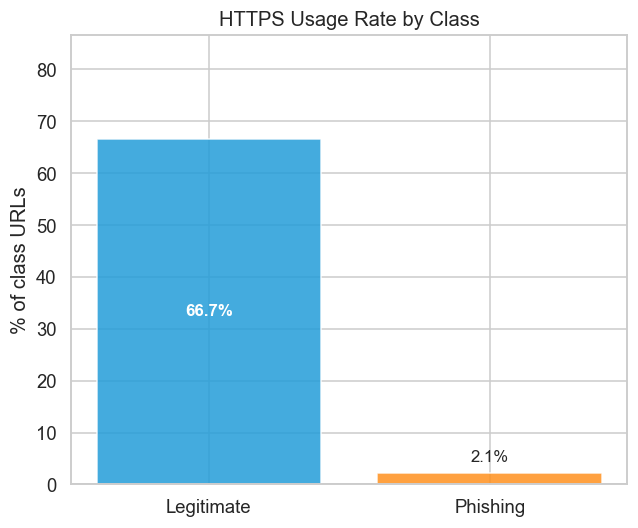

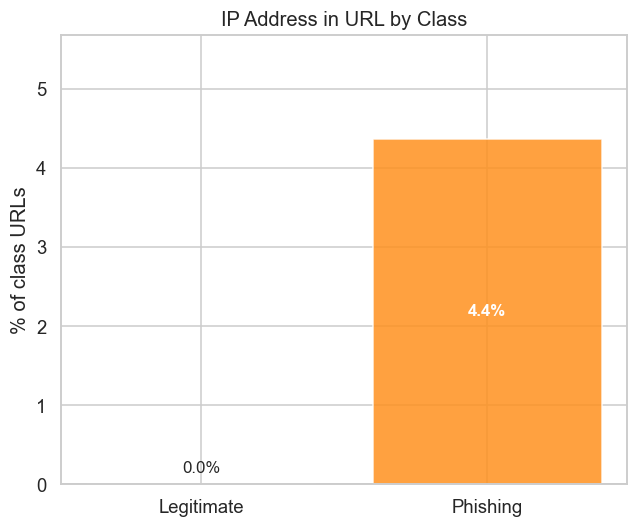

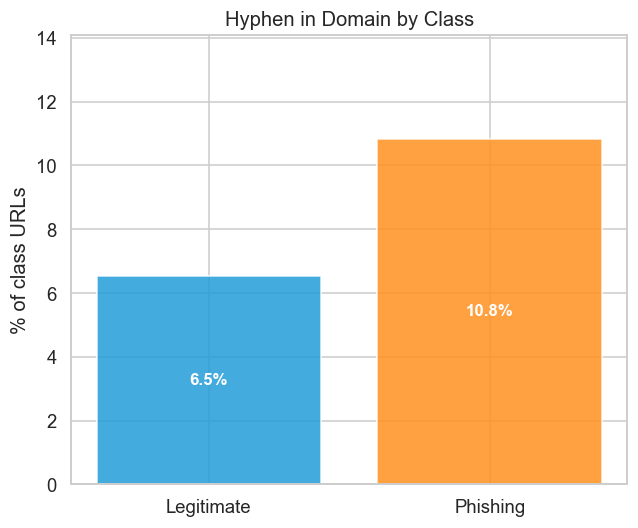

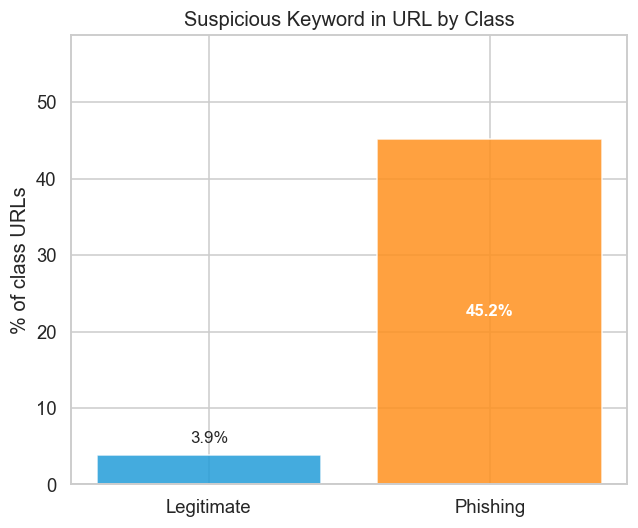

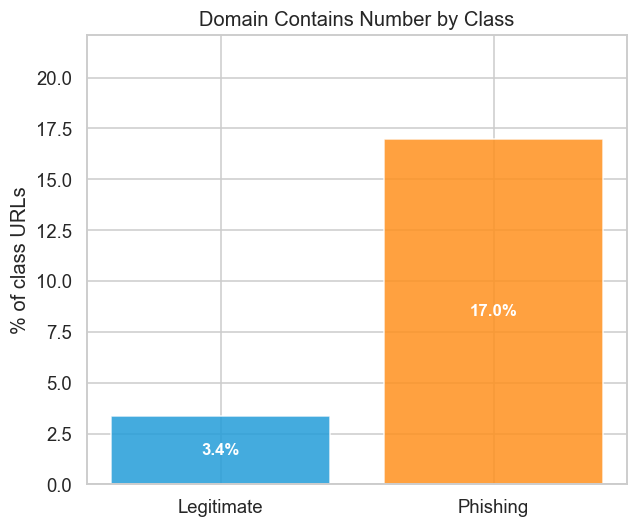

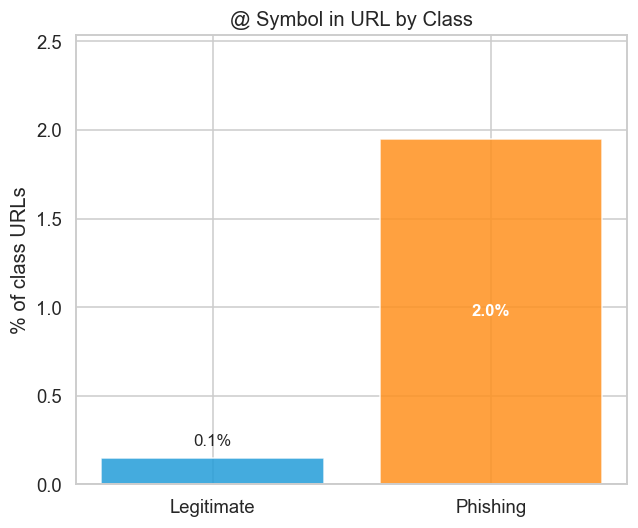

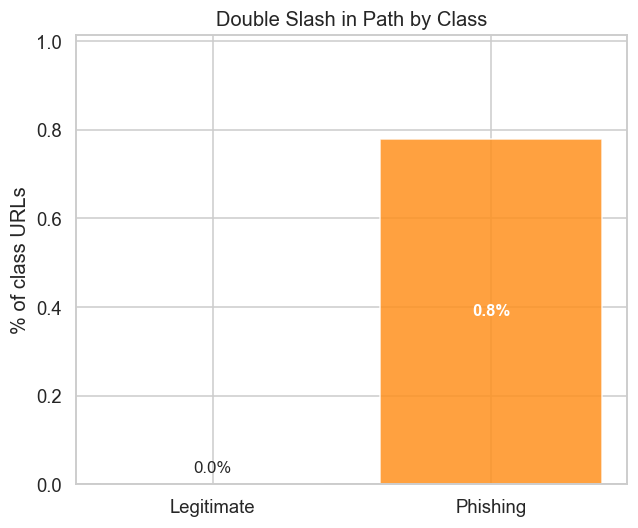

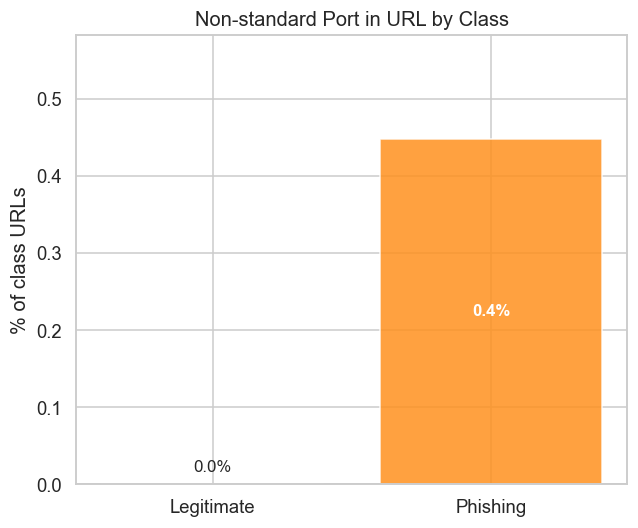

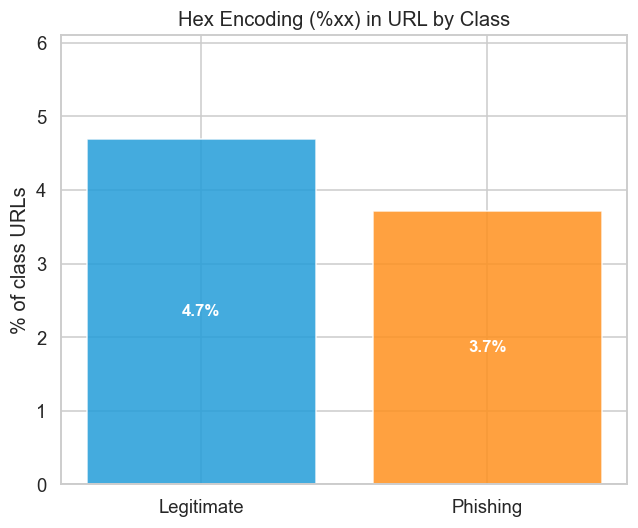

In [13]:
binary_configs = [
    ('IsHTTPS',             'HTTPS Usage Rate'),
    ('HasIPAddress',        'IP Address in URL'),
    ('HasHyphenInDomain',   'Hyphen in Domain'),
    ('HasSuspiciousKeyword','Suspicious Keyword in URL'),
    ('DomainHasNumber',     'Domain Contains Number'),
    ('HasAtSymbol',         '@ Symbol in URL'),
    ('HasDoubleSlashInPath','Double Slash in Path'),
    ('URLHasPort',          'Non-standard Port in URL'),
    ('HasHexEncoding',      'Hex Encoding (%xx) in URL'),
]

for col, title in binary_configs:
    plot_binary_rate(analysis_df, col, title=f'{title} by Class')

### 6.4 Outlier Analysis (IQR Rule)

Outliers defined as values outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`.
High outlier rates signal heavy-tailed distributions that benefit from log-transformation before modelling.

In [14]:
records = []
for col in NUMERIC_FEATURES:
    q1, q3 = analysis_df[col].quantile(0.25), analysis_df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - IQR_MULTIPLIER * iqr, q3 + IQR_MULTIPLIER * iqr
    n_out = int(((analysis_df[col] < lo) | (analysis_df[col] > hi)).sum())
    records.append({'Feature': col, 'Q1': round(q1, 3), 'Q3': round(q3, 3),
                    'IQR': round(iqr, 3), 'Outliers': n_out,
                    'OutlierPct': round(n_out / len(analysis_df) * 100, 2)})

outlier_summary = pd.DataFrame(records)
display(outlier_summary.sort_values('OutlierPct', ascending=False).reset_index(drop=True))

,Feature,Q1,Q3,IQR,Outliers,OutlierPct
0,NoOfQueryParams,0.000,0.000,0.000,933021,18.00
1,NoOfSubDomain,0.000,0.000,0.000,888486,17.14
2,SubdomainLength,0.000,0.000,0.000,888486,17.14
3,NoOfDots,2.000,3.000,1.000,665673,12.84
4,NoOfDashInURL,0.000,2.000,2.000,580482,11.20
5,NoOfDigitsInURL,0.000,9.000,9.000,533193,10.29
6,URLLength,47.000,92.000,45.000,336379,6.49
7,DigitRatioInURL,0.000,0.125,0.125,310612,5.99
8,NoOfLettersInURL,35.000,68.000,33.000,268251,5.18
9,NoOfSpecialCharsInURL,9.000,15.000,6.000,232344,4.48


### 6.5 Feature Correlation Matrix (Spearman)

Spearman correlation is used (robust to non-normal distributions).
Pairs with |r| ≥ 0.80 are candidates for removal in the feature selection step (notebook 03).

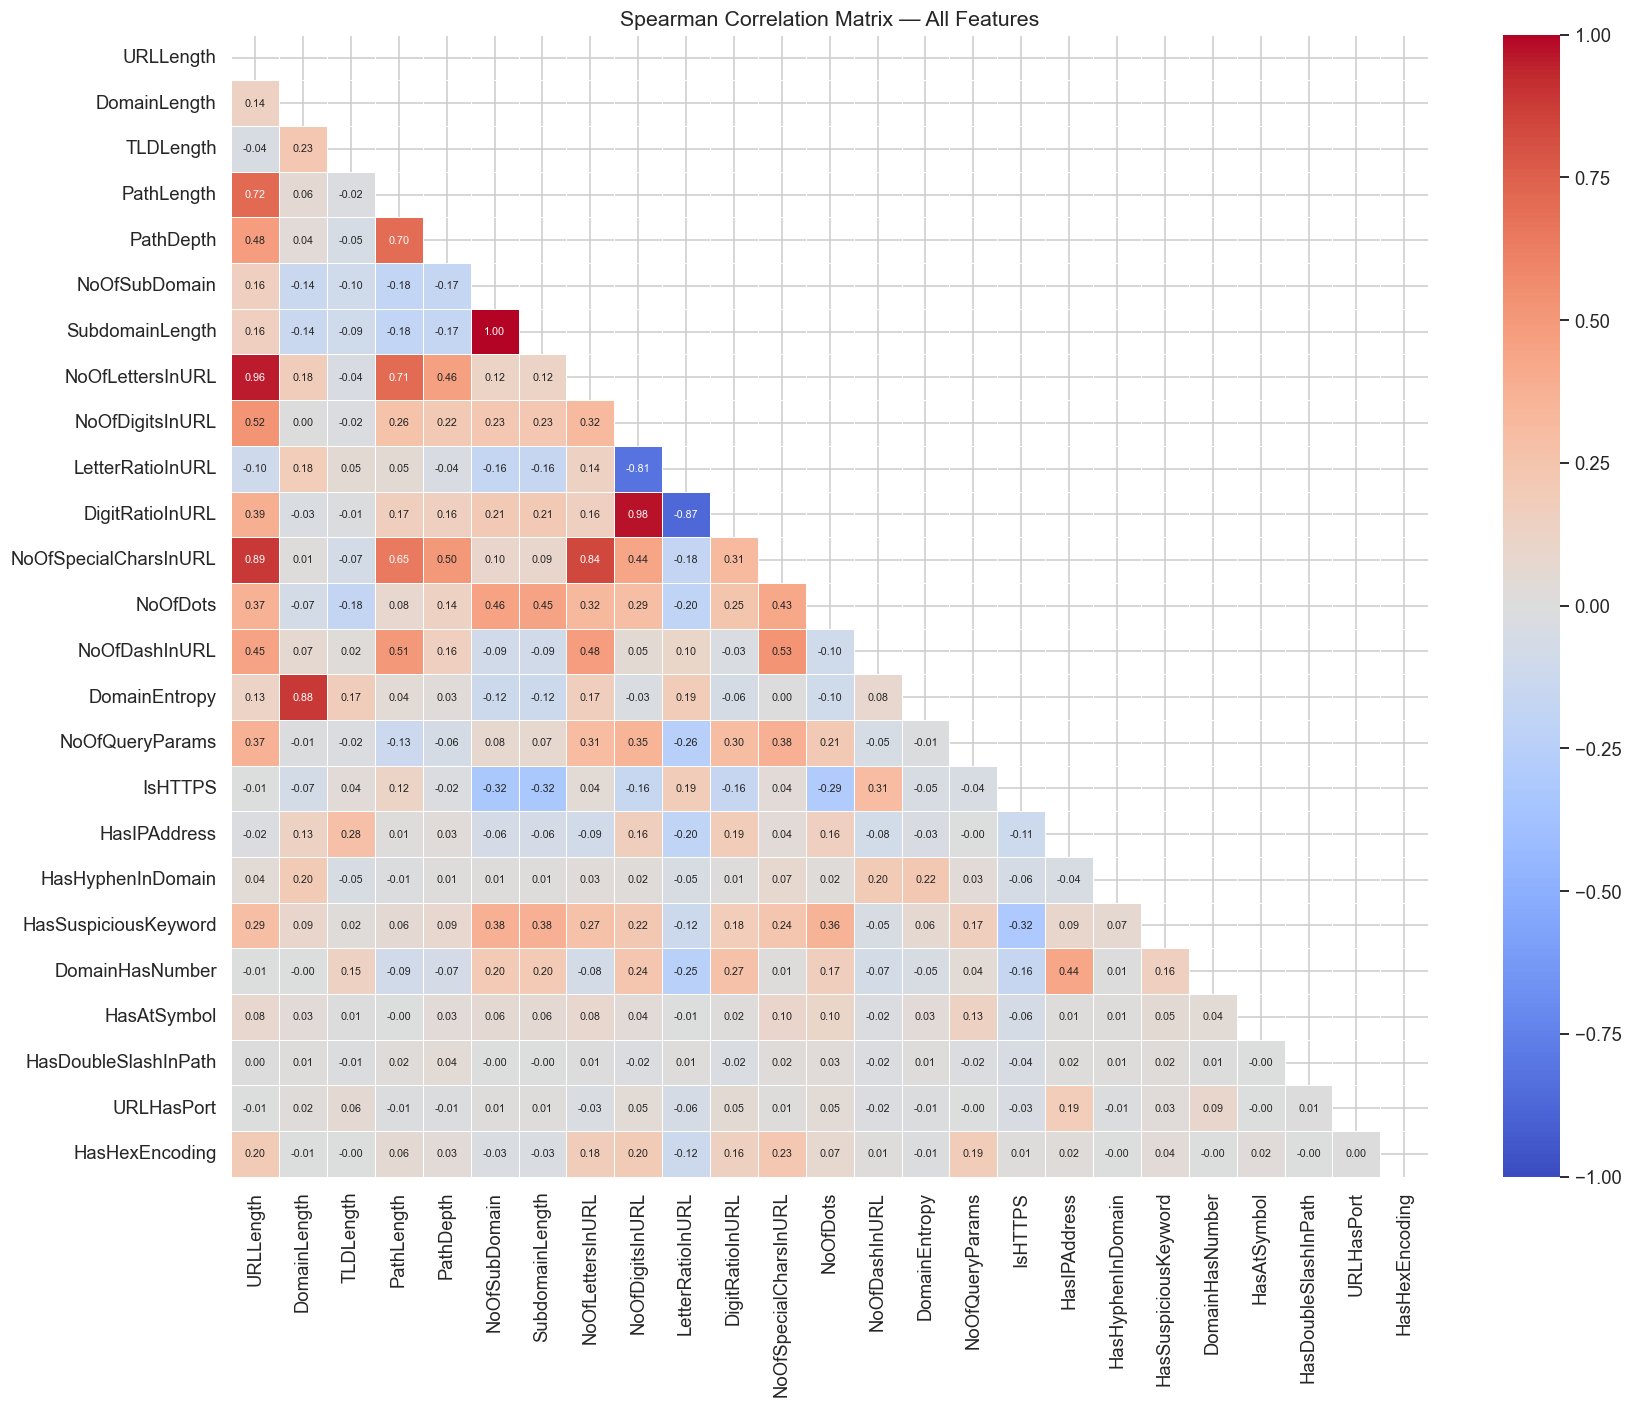


Highly correlated pairs (|r| ≥ 0.80):


,Feature A,Feature B,Spearman r
3,NoOfSubDomain,SubdomainLength,0.998
6,NoOfDigitsInURL,DigitRatioInURL,0.976
0,URLLength,NoOfLettersInURL,0.957
1,URLLength,NoOfSpecialCharsInURL,0.887
2,DomainLength,DomainEntropy,0.883
4,NoOfLettersInURL,NoOfSpecialCharsInURL,0.843
5,NoOfDigitsInURL,LetterRatioInURL,-0.813
7,LetterRatioInURL,DigitRatioInURL,-0.867


In [15]:
corr_cols = NUMERIC_FEATURES + BINARY_FEATURES
corr_matrix = analysis_df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Spearman Correlation Matrix — All Features', fontsize=14)
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= 0.80:
            high_corr.append({'Feature A': corr_matrix.columns[i],
                               'Feature B': corr_matrix.columns[j],
                               'Spearman r': round(r, 3)})

if high_corr:
    print(f'\nHighly correlated pairs (|r| ≥ 0.80):')
    display(pd.DataFrame(high_corr).sort_values('Spearman r', ascending=False))
else:
    print('No pairs with |r| ≥ 0.80 found.')

### 6.6 Skewness Analysis & Log-Transform Validation

Features with |skew| > 0.5 are log1p-transformed in the modelling notebook before scaling.
This section identifies which features need transformation and confirms the transform reduces skew.

In [16]:
skewness = analysis_df[NUMERIC_FEATURES].skew().sort_values(ascending=False)
skewed_features = skewness[skewness.abs() > 0.5]

print(f'Features with |skew| > 0.5: {len(skewed_features)} / {len(NUMERIC_FEATURES)}')
print()
skew_df = pd.DataFrame({
    'Skewness (original)': skewness,
    'Needs log1p': skewness.abs() > 0.5,
})
display(skew_df.style.background_gradient(subset=['Skewness (original)'], cmap='RdYlGn_r'))

# Validate: compare skewness before/after log1p
log_skew = {}
for col in skewed_features.index:
    transformed = np.log1p(analysis_df[col].clip(lower=0))
    log_skew[col] = round(transformed.skew(), 3)

comparison = pd.DataFrame({
    'Skewness (original)': skewed_features.round(3),
    'Skewness (log1p)':    pd.Series(log_skew),
    'Improvement': (skewed_features.abs() - pd.Series(log_skew).abs()).round(3),
})
print('\nSkewness before/after log1p:')
display(comparison)

Features with |skew| > 0.5: 16 / 16



,Skewness (original),Needs log1p
NoOfSpecialCharsInURL,15.412505,True
NoOfLettersInURL,8.569827,True
URLLength,6.707275,True
SubdomainLength,6.163153,True
NoOfQueryParams,6.053373,True
NoOfDigitsInURL,5.982402,True
NoOfSubDomain,5.690534,True
PathLength,4.939051,True
NoOfDots,4.342096,True
TLDLength,3.017759,True



Skewness before/after log1p:


,Skewness (original),Skewness (log1p),Improvement
NoOfSpecialCharsInURL,15.413,0.940,14.473
NoOfLettersInURL,8.570,0.156,8.414
URLLength,6.707,0.481,6.226
SubdomainLength,6.163,2.129,4.034
NoOfQueryParams,6.053,2.380,3.673
NoOfDigitsInURL,5.982,0.559,5.423
NoOfSubDomain,5.691,2.648,3.043
PathLength,4.939,-0.984,3.955
NoOfDots,4.342,0.929,3.413
TLDLength,3.018,1.322,1.696


### 6.7 Conclusion — Correlation-Based Feature Pruning

Features with |Spearman r| ≥ 0.80 are candidates for removal to reduce redundancy before modelling.
Model-based decisions (importance, SHAP) are deferred to `03_modeling.ipynb` Section 12.

| Pair | r | Drop | Keep | Reason |
|---|---|---|---|---|
| `NoOfSubDomain` / `SubdomainLength` | 0.998 | `SubdomainLength` | `NoOfSubDomain` | Near-perfect correlation; count is more interpretable |
| `NoOfDigitsInURL` / `DigitRatioInURL` | 0.976 | `NoOfDigitsInURL` | `DigitRatioInURL` | Ratio is scale-invariant (normalised by URL length) |
| `URLLength` / `NoOfLettersInURL` | 0.957 | `NoOfLettersInURL` | `URLLength` | Letter count is redundant given URL length |
| `LetterRatioInURL` / `DigitRatioInURL` | -0.867 | `LetterRatioInURL` | `DigitRatioInURL` | Ratios are near-mirror images; digit ratio is more indicative of phishing |
| `DomainLength` / `DomainEntropy` | 0.883 | — | Both kept | Correlation not extreme enough to drop on correlation alone |
| `URLLength` / `NoOfSpecialCharsInURL` | 0.887 | — | Both kept | Correlation not extreme enough to drop on correlation alone |

**Dropped (4 features):** `SubdomainLength`, `NoOfDigitsInURL`, `NoOfLettersInURL`, `LetterRatioInURL`

**Retained: 21 features** — used as `FEATURES` in `03_modeling.ipynb`.